# Synthesizing a table with `LanguageModelSynthesizer`

`LanguageModelSynthesizer` fits on a table with no fixed target and samples whole rows from the
learned joint. A row is generated one column at a time, each conditioned on the cells already
produced:

$$ p(x_1,\dots,x_d) = p\!\left(x_{\pi(1)}\right)\prod_{k=2}^{d} p\!\left(x_{\pi(k)} \mid x_{\pi(1)},\dots,x_{\pi(k-1)}\right). $$

Because training permuted the order $\pi$, generation can start from any column. Here sampling is
conditioned on the species, so each row is a draw from $p(\text{features} \mid \text{species})$,
and the synthetic table is compared with real Iris on per-feature moments, class structure and
label balance.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

from sklm import GenerationConfig, LanguageModelSynthesizer, TrainingConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
N_SYNTH = 150

## Data: the full Iris table

In [2]:
iris = load_iris(as_frame=True)
numeric = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
real = iris.data.set_axis(numeric, axis=1).round(1)
real["species"] = iris.target_names[iris.target]
real.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Fine-tuning

No target is fixed: with order permutation every column is a target at some point.

In [3]:
synthesizer = LanguageModelSynthesizer(
    backend="mlx",
    model="mlx-community/distilgpt2",
    training=TrainingConfig(epochs=40, batch_size=8),
    random_state=SEED,
).fit(real)

## Conditional sampling per species

A sequence of `condition` mappings gives one fixed-column spec per row and overrides `n_samples`.
`sample` retries malformed rows and raises if any stays broken, so the returned table is always
complete. `temperature > 0` is what gives the rows their diversity.

In [4]:
labels = list(iris.target_names)
per_class = N_SYNTH // len(labels)
condition = [{"species": label} for label in labels for _ in range(per_class)]

synth = synthesizer.sample(condition=condition, generation=GenerationConfig(temperature=1.0))
print(f"synthetic rows: {len(synth)}")
synth.head()

synthetic rows: 150


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.0,3.6,1.8,0.3,setosa
1,4.3,3.3,1.5,0.5,setosa
2,5.6,3.7,1.7,0.3,setosa
3,4.9,3.6,1.1,0.3,setosa
4,4.6,3.7,1.9,0.3,setosa


## Per-feature moments and distributions

In [5]:
pd.DataFrame({
    "real_mean": real[numeric].mean(),
    "synth_mean": synth[numeric].mean(),
    "real_std": real[numeric].std(),
    "synth_std": synth[numeric].std(),
}).round(2)

,real_mean,synth_mean,real_std,synth_std
sepal_length,5.84,5.91,0.83,0.87
sepal_width,3.06,3.08,0.44,0.52
petal_length,3.76,3.83,1.77,1.77
petal_width,1.20,1.26,0.76,0.80


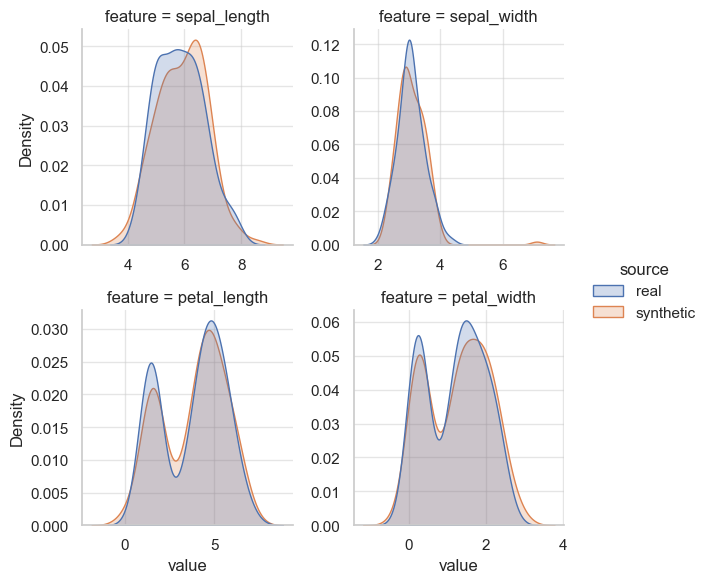

In [6]:
long = pd.concat(
    [real.assign(source="real"), synth.assign(source="synthetic")], ignore_index=True
)
melted = long.melt(
    id_vars=["species", "source"], value_vars=numeric, var_name="feature", value_name="value"
)

g = sns.displot(
    melted, x="value", hue="source", col="feature", kind="kde", fill=True,
    col_wrap=2, height=3, facet_kws={"sharex": False, "sharey": False},
)
plt.show()

## Class structure

The three synthetic species should separate in petal space like the real ones.

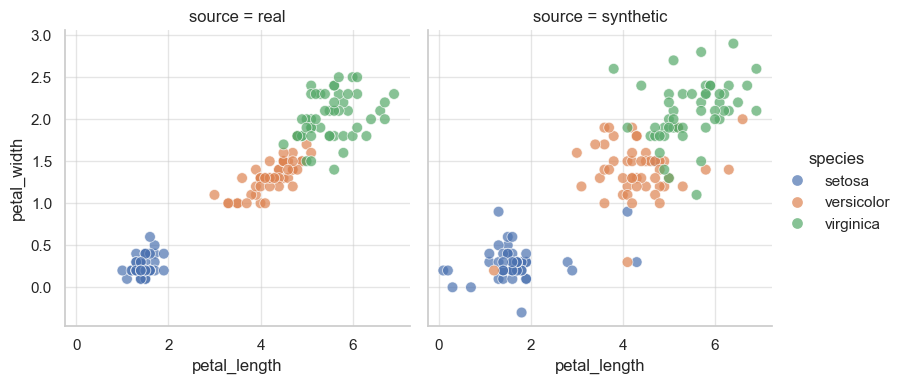

In [7]:
g = sns.relplot(
    long, x="petal_length", y="petal_width", hue="species", col="source",
    s=60, alpha=0.7, height=4,
)
plt.show()

## Class balance

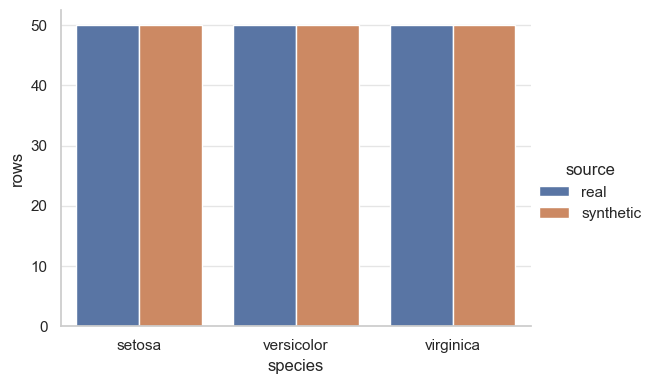

In [8]:
balance = (
    pd.DataFrame({
        "real": real["species"].value_counts(),
        "synthetic": synth["species"].value_counts(),
    })
    .reset_index(names="species")
    .melt(id_vars="species", var_name="source", value_name="n")
)

g = sns.catplot(balance, kind="bar", x="species", y="n", hue="source", height=4, aspect=1.4)
g.set_axis_labels("species", "rows")
plt.show()